In [ ]:
**Load the data**

In [15]:
import pandas as pd
data=pd.read_csv('Weather Dataset.csv')

**Data Dictionary**\
Date/Time: Date with Hour\
Temp_C: Temperature in Degrees Celsius\
Dew Point Temp_C: Dew in Degrees Celsius\
Rel Hum_%: Moisture in the air\
Wind Speed_km/h: Speed of the wind in Kilometers per Hour\
Visibility_km: Distance a person can see\
Press_kPa: Atmospheric Pressure\
Weather: Observed weather

**Exploratory Data Analysis**

In [16]:
data.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [17]:
data.shape

(8784, 8)

In [18]:
data.dtypes

Date/Time            object
Temp_C              float64
Dew Point Temp_C    float64
Rel Hum_%             int64
Wind Speed_km/h       int64
Visibility_km       float64
Press_kPa           float64
Weather              object
dtype: object

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [20]:
data.nunique()

Date/Time           8784
Temp_C               533
Dew Point Temp_C     489
Rel Hum_%             83
Wind Speed_km/h       34
Visibility_km         24
Press_kPa            518
Weather               50
dtype: int64

In [21]:
data.describe()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623
std,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005
min,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000
25%,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000
50%,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000
75%,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000
max,33.000000,24.400000,100.000000,83.000000,48.300000,103.650000


**Visualizing Temprature and Humidity**

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 9.444444444444438, 'Temperature (Celsius)')

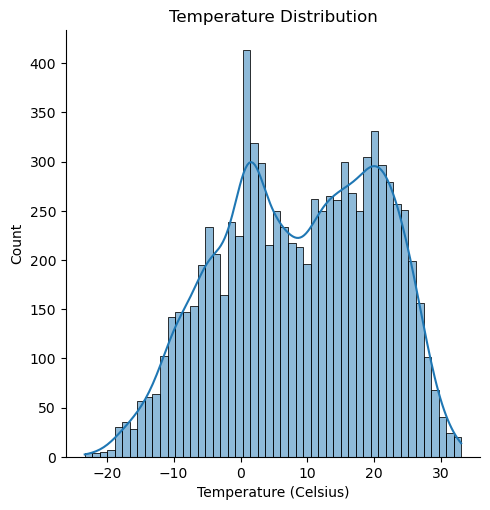

In [23]:
sns.displot(data['Temp_C'], bins=50, kde=True)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (Celsius)')

Text(0.5, 9.444444444444438, 'Humidity (Percentage)')

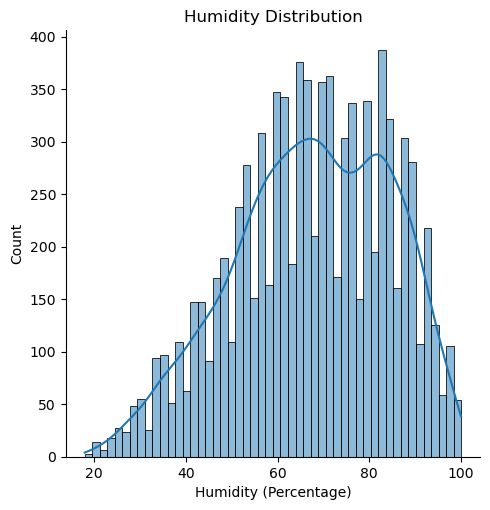

In [24]:
sns.displot(data['Rel Hum_%'], bins=50, kde=True)
plt.title('Humidity Distribution')
plt.xlabel('Humidity (Percentage)')

**Analyzing Trends Over Time**

In [25]:
# Convert Date/Time to datetime and set as index
data['Date/Time'] = pd.to_datetime(data['Date/Time'])
data.set_index('Date/Time', inplace=True)

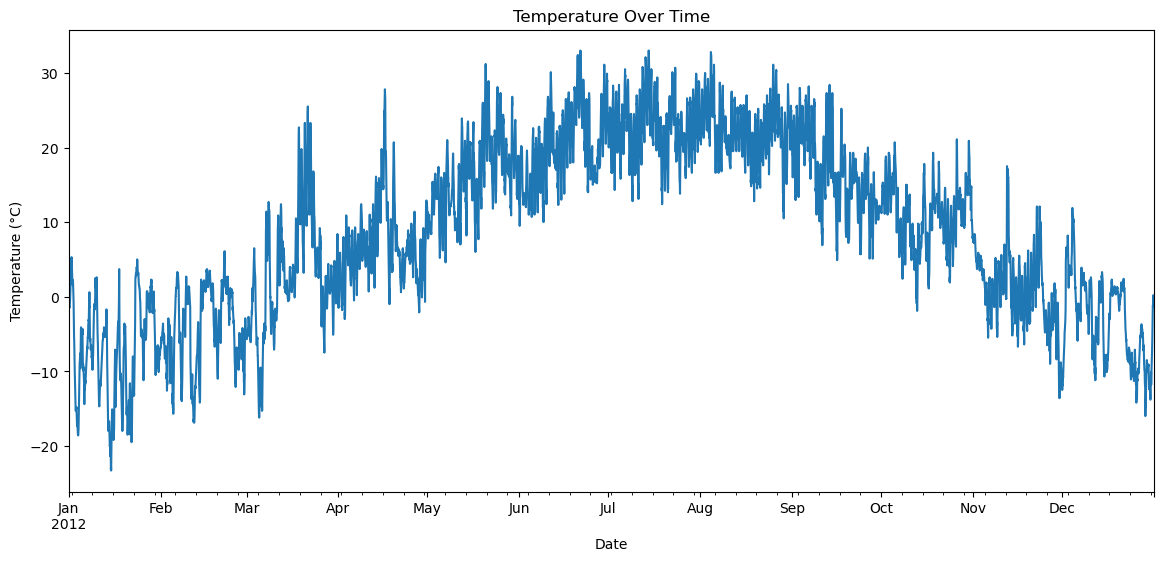

In [26]:
# Plot temperature over time
plt.figure(figsize=(14, 6))
data['Temp_C'].plot()
plt.title('Temperature Over Time')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.show()

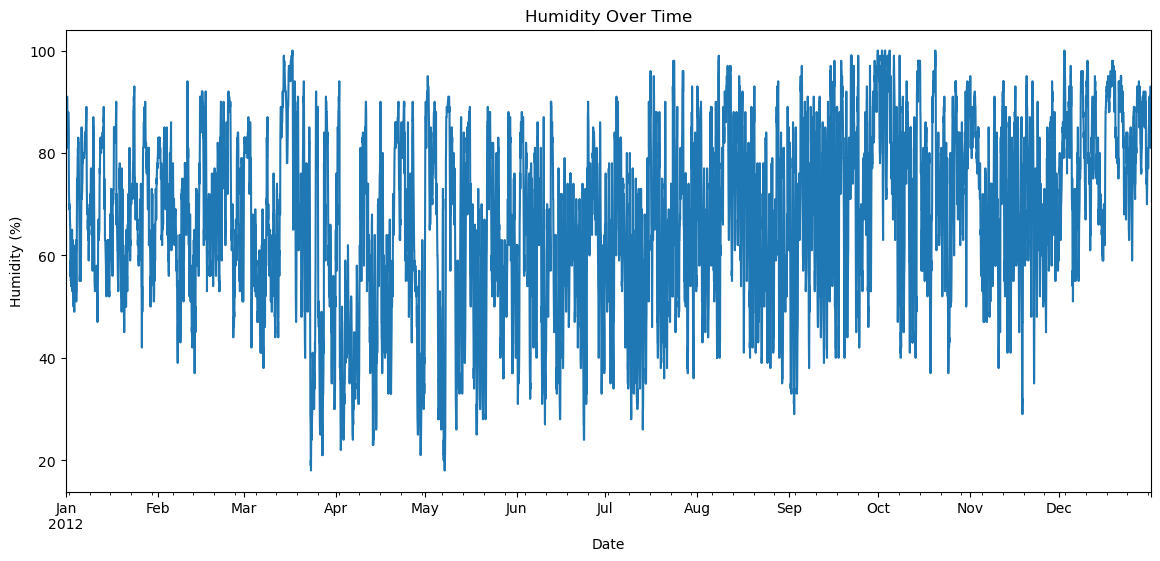

In [27]:
# Plot humidity over time
plt.figure(figsize=(14, 6))
data['Rel Hum_%'].plot()
plt.title('Humidity Over Time')
plt.ylabel('Humidity (%)')
plt.xlabel('Date')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_6552\2333444769.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = data['Temp_C'].resample('M').mean()


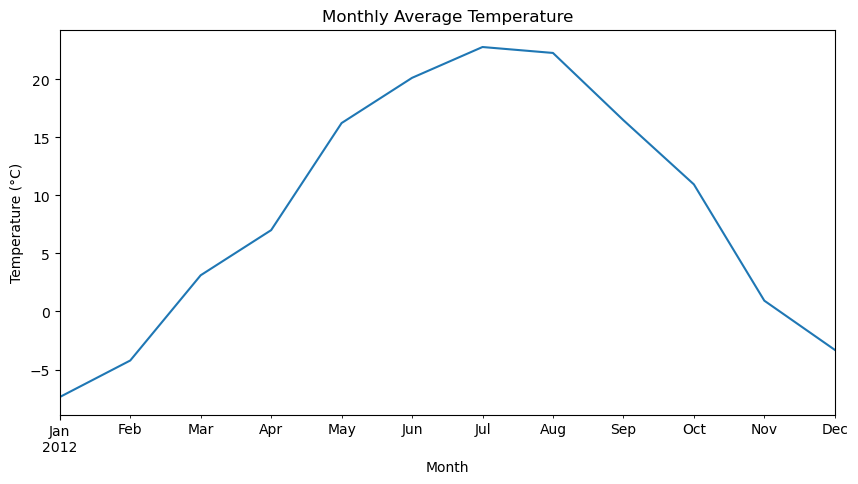

In [28]:
# Monthly average temperature
monthly_temp = data['Temp_C'].resample('M').mean()
plt.figure(figsize=(10, 5))
monthly_temp.plot()
plt.title('Monthly Average Temperature')
plt.ylabel('Temperature (°C)')
plt.xlabel('Month')
plt.show()

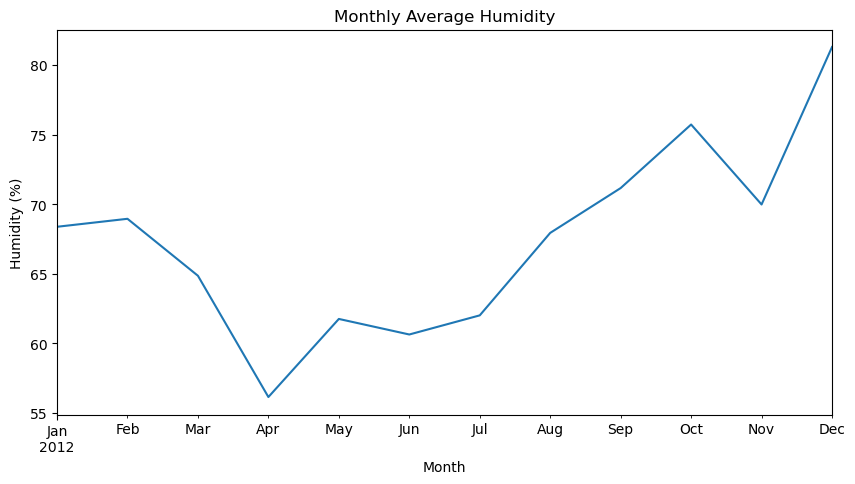

In [29]:
# Monthly average humidity
monthly_hum = data['Rel Hum_%'].resample('ME').mean()
plt.figure(figsize=(10, 5))
monthly_hum.plot()
plt.title('Monthly Average Humidity')
plt.ylabel('Humidity (%)')
plt.xlabel('Month')
plt.show()

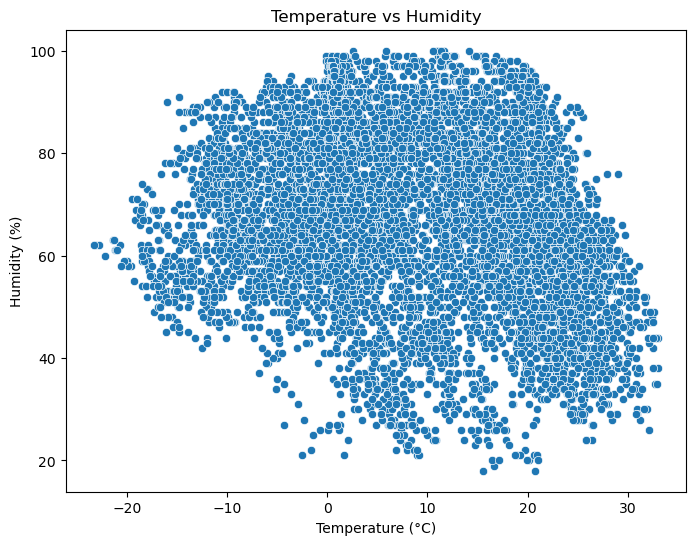

In [30]:
# Scatter plot of Temperature vs Humidity
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Temp_C', y='Rel Hum_%', data=data)
plt.title('Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.show()

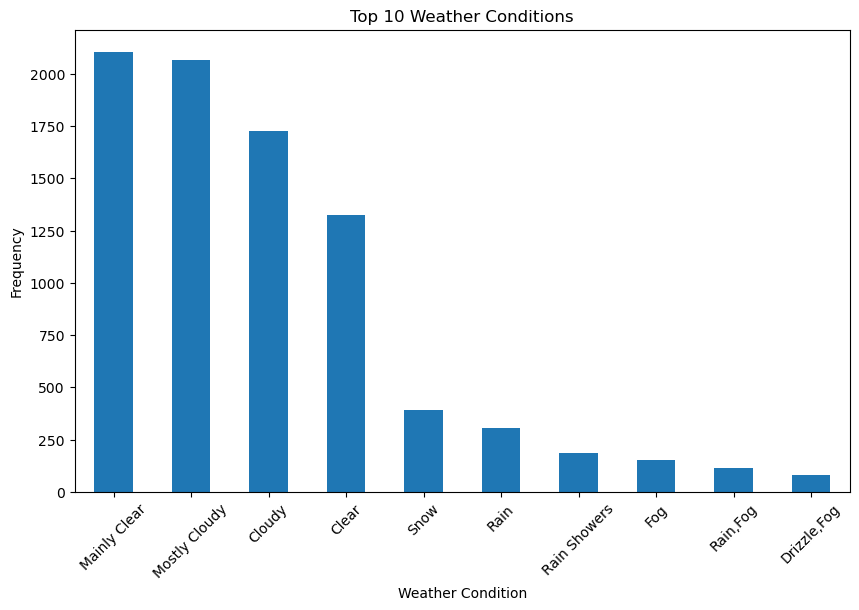

In [31]:
# Weather conditions frequency
weather_counts = data['Weather'].value_counts().head(10)  # Top 10
plt.figure(figsize=(10, 6))
weather_counts.plot(kind='bar')
plt.title('Top 10 Weather Conditions')
plt.ylabel('Frequency')
plt.xlabel('Weather Condition')
plt.xticks(rotation=45)
plt.show()